### Imports

In [38]:
import xarray as xr
import geopandas as gpd
import numpy as np

### Load Data

In [39]:
variables = xr.open_dataset("../data_cache/loadedData/pilot_aligned.nc")
blines = gpd.read_file("../data_cache/loadedData/pilot_blines_exploded.gpkg")

FLOWERING_SEASON = {
    1: 0.0,   # Jan
    2: 0.1,   # Feb
    3: 0.4,   # Mar
    4: 0.7,   # Apr
    5: 1.0,   # May
    6: 1.0,   # Jun
    7: 1.0,   # Jul
    8: 0.8,   # Aug
    9: 0.5,   # Sep
    10: 0.2,  # Oct
    11: 0.0,  # Nov
    12: 0.0,  # Dec
}

LANDCOVER_SUITABILITY = {
    10: 0.7,  # Tree cover
    20: 0.9,  # Shrubland
    30: 1.0,  # Grassland
    40: 0.6,  # Cropland
    50: 0.0,  # Built-up
    60: 0.1,  # Bare/sparse vegetation
    80: 0.0,  # Water
    90: 0.7,  # Herbaceous wetland
}

variables

<xarray.Dataset> Size: 2kB
Dimensions:      (latitude: 7, longitude: 9)
Coordinates:
  * latitude     (latitude) float64 56B 51.5 51.25 51.0 50.75 50.5 50.25 50.0
  * longitude    (longitude) float64 72B -4.5 -4.25 -4.0 ... -3.0 -2.75 -2.5
Data variables:
    temperature  (latitude, longitude) float32 252B ...
    spei         (latitude, longitude) float32 252B ...
    ndvi         (latitude, longitude) float64 504B ...
    landcover    (latitude, longitude) float64 504B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      63
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

### Scoring Functions

In [40]:
def heat_score(temp_c, temp_opt: float=20, sigma: float=6) -> float:
    return np.exp(-((temp_c - temp_opt)**2) / (2 * sigma**2))
    
def drought_score(spei: float) -> float:
    return np.clip((spei + 2) / 2, 0, 1)

def landcover_score(code: int) -> float:
    return LANDCOVER_SUITABILITY.get(code, 0.0)

def flowering_score(month: int) -> float:
    return FLOWERING_SEASON[month]

def ndvi_score(ndvi: float) -> float:
    return np.clip(ndvi, 0, 1)

def habitat_quality(ndvi: float,landcover: float,flowering: float) -> float:
    return (0.5 * ndvi_score(ndvi) + 0.3 * landcover + 0.2 * flowering)



def suitability(heat: float, drought: float, habitat: float) -> float:
    return np.minimum(heat, drought) * habitat #Liebegs Law of the minimum

In [41]:
heat_suit = xr.apply_ufunc(
    heat_score,
    variables["temperature"],
    vectorize=True
)

drought_suit = xr.apply_ufunc(
    drought_score,
    variables["spei"],
    vectorize=True
)

landcover_suit = xr.apply_ufunc(
    landcover_score,
    variables["landcover"],
    vectorize=True
)

month = 7
flowering_suit = flowering_score(month)

flowering_grid = xr.full_like(
    variables["temperature"],
    flowering_suit
)

habitat_suit = xr.apply_ufunc(
    habitat_quality,
    variables["ndvi"],
    landcover_suit,
    flowering_grid,
    vectorize=True
)

final_suitability = xr.apply_ufunc(
    suitability,
    heat_suit,
    drought_suit,
    habitat_suit,
    vectorize=True
)

pollinator_ds = xr.Dataset(
    {
        "heat_suitability": heat_suit,
        "drought_suitability": drought_suit,
        "habitat_quality": habitat_suit,
        "pollinator_suitability": final_suitability,
    }
)

pollinator_ds.values

<bound method Mapping.values of <xarray.Dataset> Size: 2kB
Dimensions:                 (latitude: 7, longitude: 9)
Coordinates:
  * latitude                (latitude) float64 56B 51.5 51.25 ... 50.25 50.0
  * longitude               (longitude) float64 72B -4.5 -4.25 ... -2.75 -2.5
Data variables:
    heat_suitability        (latitude, longitude) float32 252B 0.6933 ... 0.6928
    drought_suitability     (latitude, longitude) float32 252B 1.0 1.0 ... 1.0
    habitat_quality         (latitude, longitude) float64 504B 0.2 0.2 ... 0.2
    pollinator_suitability  (latitude, longitude) float64 504B 0.1387 ... 0.1386>

In [42]:
print(pollinator_ds.pollinator_suitability.min())
print(pollinator_ds.pollinator_suitability.max())

<xarray.DataArray 'pollinator_suitability' ()> Size: 8B
array(0.1326378)
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      63
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0
<xarray.DataArray 'pollinator_suitability' ()> Size: 8B
array(0.89801951)
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      

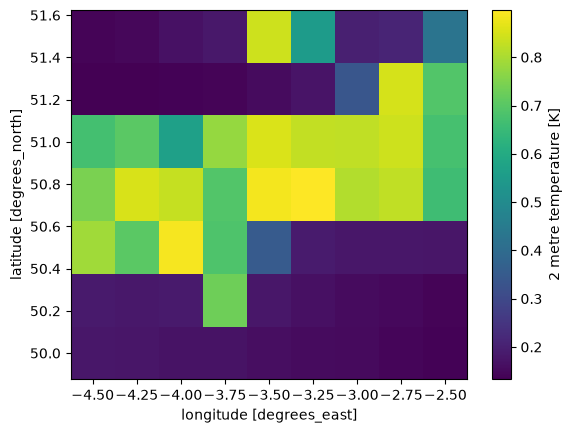

In [43]:
pollinator_ds.pollinator_suitability.plot()

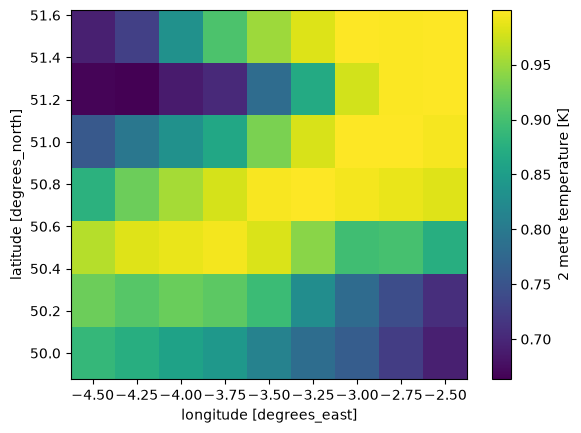

In [44]:
pollinator_ds["heat_suitability"].plot()

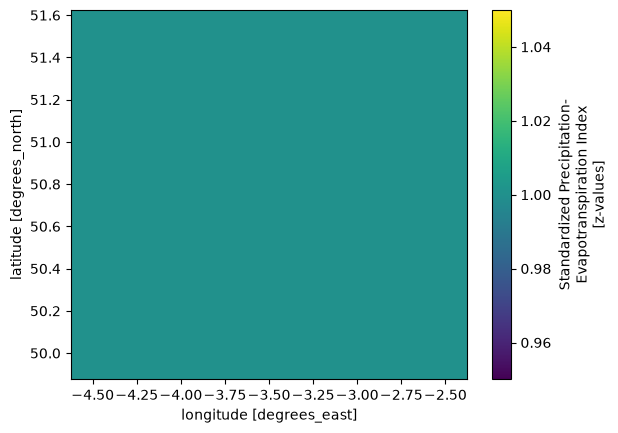

In [45]:
pollinator_ds["drought_suitability"].plot()

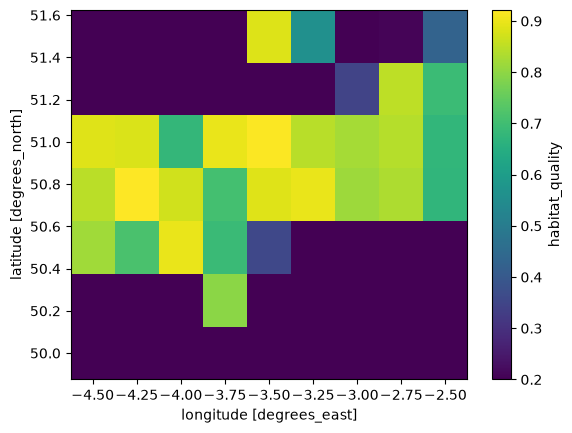

In [46]:
pollinator_ds["habitat_quality"].plot()

In [47]:
print(variables["spei"].min().values)
print(variables["spei"].max().values)

0.9106232
1.644601


In [48]:
print(np.unique(variables["spei"].values))

[0.9106232 0.9851286 1.0356697 1.1253278 1.1634206 1.1809056 1.1833675
 1.2437427 1.2719443 1.2872945 1.2966238 1.3749142 1.644601 ]


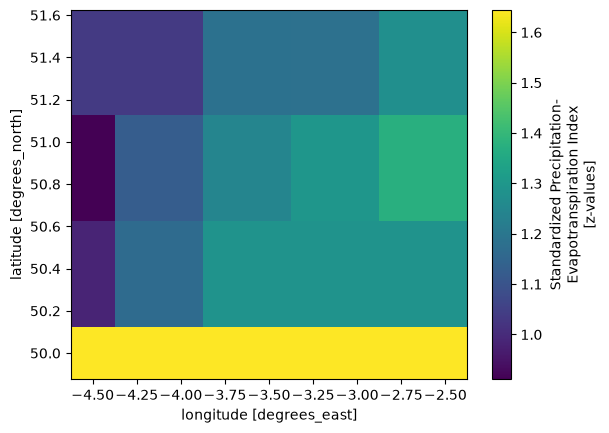

In [49]:
variables["spei"].plot()